# Quick start: geometry and one radial profile

        ## Author

        [Rafael S. de Souza](https://rafaelsdesouza.com.br/)

        ## Learning goals

        - provide support and centres
- inspect centre assignment and both coordinates
- compute a centre-conditioned profile

        ## Keywords

        support mask, supplied centres, radial profile

        ## Summary

        Construct two coordinates on a connected irregular mask and measure a scalar field.

        ## Resources

        - [Documentation](https://rafaelsdesouza.com.br/multiradial/docs/)
        - [Source](https://github.com/RafaelSdeSouza/multiradial)
        - Paper/preprint: bibliographic link pending
        - [Citation metadata](https://github.com/RafaelSdeSouza/multiradial/blob/main/CITATION.cff)

        Execute this notebook from a local checkout. A Colab installation link
        will be added only after the first immutable release tag exists.

In [1]:
from pathlib import Path
import sys
source = Path("src") if Path("src/radialpaths").exists() else Path("../src")
if str(source.resolve()) not in sys.path:
    sys.path.insert(0, str(source.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from radialpaths import build_geometry, radial_profile

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11, "axes.linewidth": 0.8})

## Define the formal inputs

`True` pixels are traversable. Supplied centres use NumPy
`(row, column)` order and must lie inside the connected support.

In [2]:
yy, xx = np.indices((81, 111), dtype=float)
support = ((xx - 52) / 43) ** 2 + ((yy - 40) / 27) ** 2 <= 1
support |= ((xx - 82) / 18) ** 2 + ((yy - 49) / 16) ** 2 <= 1
centres = [(37, 30), (47, 76)]
geometry = build_geometry(support, centres)

intensity = np.full(support.shape, np.nan)
intensity[support] = np.exp(-geometry.centre_distance[support] / 14)
intensity[support] += 0.08 * xx[support] / support.shape[1]
profile = radial_profile(intensity, geometry, coordinate="rho_X")
print(geometry.rho_D.dtype, geometry.rho_X.dtype)
print(profile.median.shape, "centre profiles by", profile.n_bins, "bins")

float64 float64
(2, 30) centre profiles by 30 bins


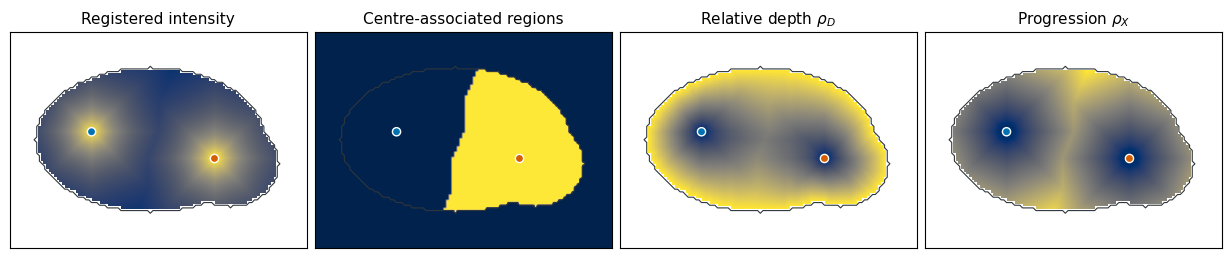

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12.2, 3.0), constrained_layout=True)
for ax, field, title in zip(
    axes,
    [intensity, geometry.labels, geometry.rho_D, geometry.rho_X],
    ["Registered intensity", "Centre-associated regions", r"Relative depth $\rho_D$", r"Progression $\rho_X$"],
):
    ax.imshow(field, cmap="cividis", origin="upper", vmin=0, vmax=1)
    ax.contour(support, [0.5], colors="#30363b", linewidths=0.8)
    ax.scatter(np.asarray(centres)[:, 1], np.asarray(centres)[:, 0], c=["#0072B2", "#D55E00"], edgecolors="white", s=35)
    ax.set(title=title, xticks=[], yticks=[])
plt.show()

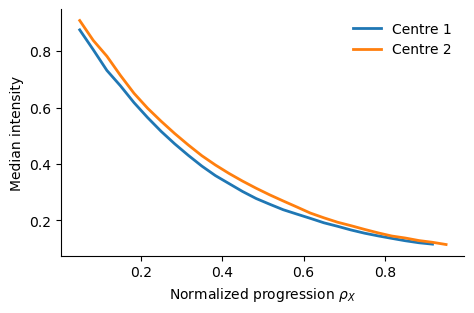

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
for centre_index, values in enumerate(profile.median):
    ax.plot(profile.radius, values, lw=2, label=f"Centre {centre_index + 1}")
ax.set(xlabel=r"Normalized progression $\rho_X$", ylabel="Median intensity")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

The support and centres fix the geometry. Changing the
registered intensity values does not recompute centre assignment
or either coordinate.